# Foreword

### This notebook
In this notebook we: 
- Open RPW L3 files with spacepy pycdf
- Plot a combined HFR-TNR dynamic spectrum
- Overplot arrows on the spectrum

### Not in this notebook
I used data files that I downloaded manually on the Solar Orbiter archive website. To download files from the SOAR using Sunpy Fido, see e.g. the notebook `RPW_download_and_plot_L2_spectrogram_(with_maser)` and adapt it for L3 dat

### Setup
My conda environment is running with:
- Python 3.12.7
- maser-data 0.4.2
- maser-plot 0.3.3
- maser-tools 0.2.0
- maser4py 0.16.1
- sunpy 6.0.3
- sunpy-soar 1.11.1
- spacepy 0.7.0

In [1]:
import sys
print(sys.version)

3.12.7 | packaged by conda-forge | (main, Oct  4 2024, 15:47:54) [MSC v.1941 64 bit (AMD64)]


### History
Last run on May 13 2026 by S. Musset

# Calls

In [2]:
from spacepy import pycdf
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.dates as mdates
import datetime
import numpy as np

# Open CDF files

In [3]:
file_tnr3 = '..\\..\\..\\data\\RPW\\solo_L3_rpw-tnr-surv-flux_20221029_V02.cdf'
file_hfr3 = '..\\..\\..\\data\\RPW\\solo_L3_rpw-hfr-surv-flux_20221029_V02.cdf'

In [4]:
tnr_data_l3 = pycdf.CDF(file_tnr3)

In [5]:
hfr_data_l3 = pycdf.CDF(file_hfr3)

### Explore file properties

In [6]:
print(hfr_data_l3.keys())

KeysView(<CDF:
ELAPSED_TIME_SINCE_EPOCH: CDF_REAL4 [14431, 50]
Epoch: CDF_TIME_TT2000 [14431]
FREQUENCY: CDF_REAL4 [50] NRV
GAMMA_LEFF: CDF_REAL4 [3] NRV
GAMMA_LEFF_ERROR: CDF_REAL4 [3] NRV
INTERPOL_FLAG: CDF_UINT1 [14431, 50]
LBL1_SC_POS_HCI: CDF_CHAR*10 [3] NRV
PSD_FLUX: CDF_REAL4 [14431, 50]
PSD_FLUX_DB: CDF_REAL4 [14431, 50]
PSD_FLUX_RELATIVE_ERROR: CDF_REAL4 [3] NRV
PSD_SFU: CDF_REAL4 [14431, 50]
PSD_V2: CDF_REAL4 [14431, 50]
QUALITY_FLAG: CDF_UINT1 [14431]
REP1_SC_POS_HCI: CDF_CHAR*10 [3] NRV
SC_POS_HCI: CDF_REAL4 [14431, 3]
SENSOR_CONFIG: CDF_UINT1 [14431]
SENSOR_LABEL: CDF_CHAR*5 [3] NRV
>)


### Assign to variables

In [7]:
tnr_psd_sfu = tnr_data_l3['PSD_SFU']
tnr_psd_time = tnr_data_l3['Epoch']
tnr_psd_freq = tnr_data_l3['FREQUENCY']

In [8]:
hfr_psd_sfu = hfr_data_l3['PSD_SFU']
hfr_psd_time = hfr_data_l3['Epoch']
hfr_psd_freq = hfr_data_l3['FREQUENCY']

In [9]:
hfr_psd_freq.attrs["UNITS"]

'Hz'

# Plot dynamic spectra

## Plot setup

In [10]:
# change the time display
locator = mdates.AutoDateLocator(minticks=3, maxticks=9)
formatter = mdates.ConciseDateFormatter(locator, show_offset=False)

## Plot TNR

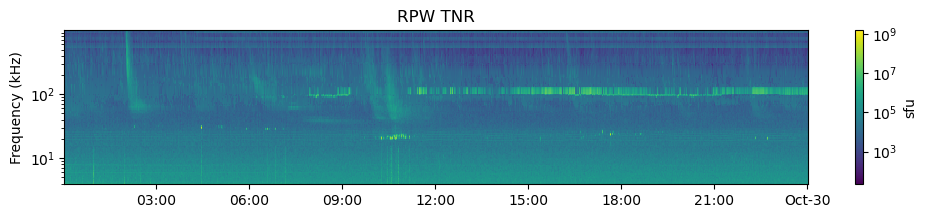

In [11]:
z = np.transpose(np.array(tnr_psd_sfu))
x, y = np.meshgrid(np.array(tnr_psd_time), np.array(tnr_psd_freq)/1e3)

fig, ax = plt.subplots(1, 1, figsize = (12, 2))

c = ax.pcolormesh(x, y, z, norm=LogNorm())   
ax.set_title('RPW TNR')

# frequency axis
ax.set_ylabel('Frequency (kHz)')
ax.set_yscale('log')

# time axis
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

cb = plt.colorbar(c)  #producing the colorbar
cb.set_label(label= tnr_psd_sfu.attrs["UNITS"])
plt.show()

## Plot HFR

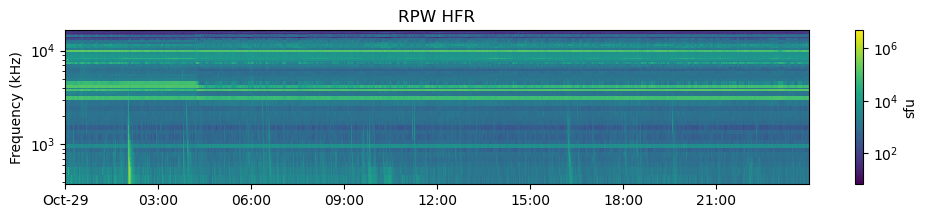

In [12]:
z = np.transpose(np.array(hfr_psd_sfu))
x, y = np.meshgrid(np.array(hfr_psd_time), np.array(hfr_psd_freq)/1e3)

fig, ax = plt.subplots(1, 1, figsize = (12, 2))

c = ax.pcolormesh(x, y, z, norm=LogNorm())   
ax.set_title('RPW HFR')

# frequency axis
ax.set_ylabel('Frequency (kHz)')
ax.set_yscale('log')

# time axis
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

cb = plt.colorbar(c)  #producing the colorbar
cb.set_label(label= tnr_psd_sfu.attrs["UNITS"])
plt.show()

## Plot combined

### Whole frequency range and time range

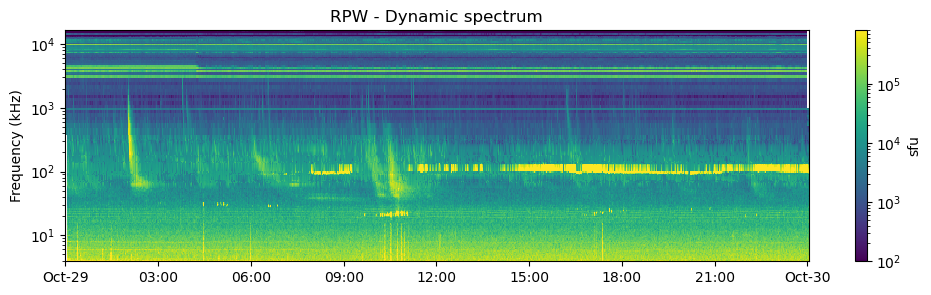

In [13]:
z_hfr = np.transpose(np.array(hfr_psd_sfu))
x_hfr, y_hfr = np.meshgrid(np.array(hfr_psd_time), np.array(hfr_psd_freq)/1e3)

z_tnr = np.transpose(np.array(tnr_psd_sfu))
x_tnr, y_tnr = np.meshgrid(np.array(tnr_psd_time), np.array(tnr_psd_freq)/1e3)

fig, ax = plt.subplots(1, 1, figsize = (12, 3))

c_tnr = ax.pcolormesh(x_tnr, y_tnr, z_tnr, norm=LogNorm(vmin=1e2, vmax=0.8e6)) 
c_hfr = ax.pcolormesh(x_hfr, y_hfr, z_hfr, norm=LogNorm(vmin=1e2, vmax=0.8e6))   

ax.set_title('RPW - Dynamic spectrum')

# time axis
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
# frequency axis
ax.set_ylabel('Frequency (kHz)')
ax.set_yscale('log')

cb = plt.colorbar(c_tnr)  #producing the colorbar
cb.set_label(label= tnr_psd_sfu.attrs["UNITS"])
plt.show()

### Adjust to interesting ranges

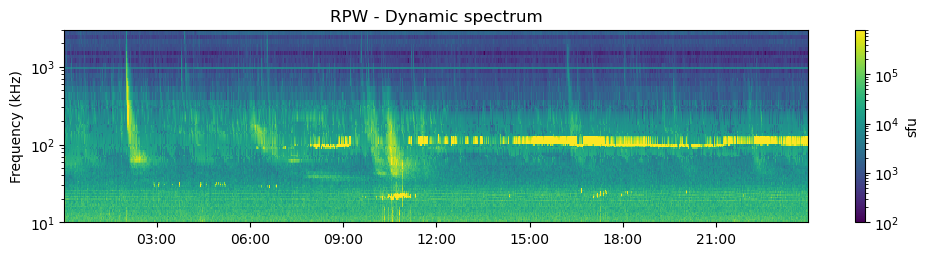

In [14]:
z_hfr = np.transpose(np.array(hfr_psd_sfu))
x_hfr, y_hfr = np.meshgrid(np.array(hfr_psd_time), np.array(hfr_psd_freq)/1e3)

z_tnr = np.transpose(np.array(tnr_psd_sfu))
x_tnr, y_tnr = np.meshgrid(np.array(tnr_psd_time), np.array(tnr_psd_freq)/1e3)

fig, ax = plt.subplots(1, 1, figsize = (12, 2.5))

c_tnr = ax.pcolormesh(x_tnr, y_tnr, z_tnr, norm=LogNorm(vmin=1e2, vmax=0.8e6)) 
c_hfr = ax.pcolormesh(x_hfr, y_hfr, z_hfr, norm=LogNorm(vmin=1e2, vmax=0.8e6))   

ax.set_title('RPW - Dynamic spectrum')

# time axis
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
# frequency axis
ax.set_ylabel('Frequency (kHz)')
ax.set_yscale('log')

#set the limits of the plot to the limits of the data
ax.axis([x_tnr.min(), x_hfr.max(), 10, 3e3])

ax.set_yscale('log')

cb = plt.colorbar(c_tnr)  #producing the colorbar
cb.set_label(label= tnr_psd_sfu.attrs["UNITS"])

plt.show()

### With white arrows for times of interest

In [15]:
injection_times = [datetime.datetime(2022,10,29,2,11,0),
                   datetime.datetime(2022,10,29,10,21,0),
                   datetime.datetime(2022,10,29,16,12,0),
                   datetime.datetime(2022,10,29,20,7,0),
                   datetime.datetime(2022,10,29,22,4,0)]

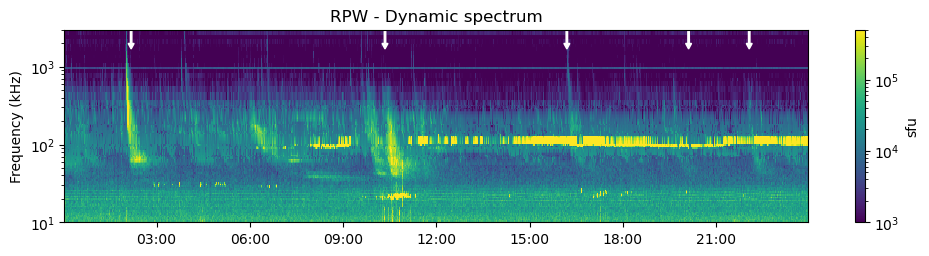

In [16]:
z_hfr = np.transpose(np.array(hfr_psd_sfu))
x_hfr, y_hfr = np.meshgrid(np.array(hfr_psd_time), np.array(hfr_psd_freq)/1e3)

z_tnr = np.transpose(np.array(tnr_psd_sfu))
x_tnr, y_tnr = np.meshgrid(np.array(tnr_psd_time), np.array(tnr_psd_freq)/1e3)

fig, ax = plt.subplots(1, 1, figsize = (12, 2.5))

c_tnr = ax.pcolormesh(x_tnr, y_tnr, z_tnr, norm=LogNorm(vmin=1e3, vmax=0.5e6)) 
c_hfr = ax.pcolormesh(x_hfr, y_hfr, z_hfr, norm=LogNorm(vmin=1e3, vmax=0.5e6))   

ax.set_title('RPW - Dynamic spectrum')

# time axis
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
# frequency axis
ax.set_ylabel('Frequency (kHz)')
ax.set_yscale('log')

#set the limits of the plot to the limits of the data
ax.axis([x_tnr.min(), x_hfr.max(), 10, 3e3])

ax.set_yscale('log')

cb = plt.colorbar(c_tnr)  #producing the colorbar
cb.set_label(label= tnr_psd_sfu.attrs["UNITS"])

for time in injection_times:
    plt.arrow(time, 3e3, 0, -1e3, width=0.002, color='white', head_width=0.008, head_length=0.3e3)

plt.show()